# Sustainability score

Module D: compare water, electricity, and nitrogen inputs against a baseline for the same crop cycle.
The examples are simulated. The score is a project-defined resource-use indicator, with a yield check.

Use the project environment with `requirements-notebooks.txt` installed. No training is needed.

## Formula, version 1.0

Normalize each resource by cultivated area:

```text
baseline_intensity = baseline_total / baseline_area_ha
current_intensity = current_total / current_area_ha
relative_reduction = (baseline_intensity - current_intensity) / baseline_intensity
component_score = clip(50 + 50 * relative_reduction, 0, 100)
raw_score = 0.40 * water_score + 0.30 * electricity_score + 0.30 * nitrogen_score
```

50 means the same input intensity as the baseline. Higher scores mean lower inputs per hectare.
The weights and scale are assumptions, not a certification standard.

Reduced inputs can also reduce yield. If current yield per hectare falls below 95% of baseline,
cap the final score at 50. This cutoff is a project setting too.
Missing inputs, zero resource baselines, or unconfirmed comparability produce no score.

## Inputs and units

Record irrigation water (m³), electricity (kWh), nitrogen nutrient (kg N), area (ha), and harvest (kg).
Include crop, location, dates, sources, and accounting scope. Use nutrient mass rather than fertilizer bag mass.
Compare equal-duration cycles with compatible growing conditions. Area can differ because totals are normalized.
Check for scope changes, such as electricity being replaced by diesel.

The extra ratio `harvest_kg / irrigation_water_m3` measures irrigation-input productivity.
[FAO's water productivity reference](https://www.fao.org/in-action/remote-sensing-for-water-productivity/wapor-data/)
uses production and water volume, but this notebook excludes rainfall and total consumed water.
Its ratio differs from WaPOR's measure, and the composite score is not an FAO formula.

Carbon emissions, soil health, biodiversity, and nutrient balance are outside the calculation.

In [1]:
from pathlib import Path
from datetime import date, datetime, timezone
import copy
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "report/bonus_modules_sources.json").is_file())
FORMULA_VERSION = "1.0"
WEIGHTS = {"water_m3": 0.40, "electricity_kwh": 0.30, "nitrogen_kg": 0.30}
UNITS = {"water_m3": "m³/ha", "electricity_kwh": "kWh/ha", "nitrogen_kg": "kg N/ha"}
YIELD_RETENTION_FLOOR = 0.95
REQUIRED_NUMBERS = ["area_ha", "harvest_kg", *WEIGHTS]
REQUIRED_TEXT = ["crop", "location", "period_start", "period_end", "basis",
                 "source_note", "water_scope", "electricity_scope", "nitrogen_scope"]

if not math.isclose(sum(WEIGHTS.values()), 1.0) or any(weight < 0 for weight in WEIGHTS.values()):
    raise ValueError("Weights must be non-negative and sum to one.")


## Validate the comparison

Both records must be measured or both simulated. Measurement sources are recorded but not independently authenticated.
Explain why the baseline is comparable; matching crop and dates alone won't remove differences in weather or soil.

In [2]:
def validate_record(record, name):
    errors = []
    for key in REQUIRED_TEXT:
        if not isinstance(record.get(key), str) or not record[key].strip():
            errors.append(f"{name}.{key}: required non-empty text")
    for key in REQUIRED_NUMBERS:
        value = record.get(key)
        if (isinstance(value, bool) or not isinstance(value, (int, float))
                or not math.isfinite(value) or value < 0):
            errors.append(f"{name}.{key}: required finite non-negative number")
    if not errors:
        if record["area_ha"] <= 0:
            errors.append(f"{name}.area_ha: must be positive")
        try:
            start = date.fromisoformat(record["period_start"])
            end = date.fromisoformat(record["period_end"])
            if end <= start:
                errors.append(f"{name}: period_end must be after period_start")
        except ValueError:
            errors.append(f"{name}: dates must use YYYY-MM-DD")
    if record.get("data_kind") not in ("simulated", "measured"):
        errors.append(f"{name}.data_kind: must be simulated or measured")
    if record.get("basis") != "whole_crop_cycle":
        errors.append(f"{name}.basis: use a completed whole_crop_cycle")
    return errors


def score_sustainability(baseline, current, *, comparable=False, comparison_note=""):
    errors = validate_record(baseline, "baseline") + validate_record(current, "current")
    if comparable is not True or not isinstance(comparison_note, str) or not comparison_note.strip():
        errors.append("Explicitly confirm comparability and provide its evidence note.")
    if errors:
        return {"status": "NEEDS_DATA", "score": None, "reasons": errors}
    matching = ["crop", "location", "basis", "water_scope", "electricity_scope", "nitrogen_scope", "data_kind"]
    for field in matching:
        if baseline[field] != current[field]:
            errors.append(f"Mismatched {field}; establish a comparable baseline.")
    durations = [(date.fromisoformat(item["period_end"]) - date.fromisoformat(item["period_start"])).days
                 for item in [baseline, current]]
    if durations[0] != durations[1]:
        errors.append("Production-cycle durations differ.")
    if baseline["harvest_kg"] <= 0:
        errors.append("Positive baseline harvest is required for the yield check.")
    for field in WEIGHTS:
        if baseline[field] <= 0:
            errors.append(f"Positive baseline {field} required; no silent component exclusion.")
    if errors:
        return {"status": "NEEDS_DATA", "score": None, "reasons": errors}

    components = []
    for field, weight in WEIGHTS.items():
        baseline_intensity = baseline[field] / baseline["area_ha"]
        current_intensity = current[field] / current["area_ha"]
        reduction = (baseline_intensity - current_intensity) / baseline_intensity
        component_score = min(100.0, max(0.0, 50.0 + 50.0 * reduction))
        components.append({"component": field, "unit": UNITS[field],
                           "baseline_per_ha": baseline_intensity, "current_per_ha": current_intensity,
                           "difference_per_ha": baseline_intensity - current_intensity,
                           "relative_reduction_pct": 100.0 * reduction,
                           "component_score": component_score, "weight": weight,
                           "weighted_points": component_score * weight})
    raw_score = sum(component["weighted_points"] for component in components)
    baseline_yield = baseline["harvest_kg"] / baseline["area_ha"]
    current_yield = current["harvest_kg"] / current["area_ha"]
    yield_retention = current_yield / baseline_yield
    yield_flag = yield_retention < YIELD_RETENTION_FLOOR
    final_score = min(raw_score, 50.0) if yield_flag else raw_score
    warnings = ["Indicative resource-use comparison, not a complete sustainability assessment.",
                "Differences cannot establish savings caused by the software."]
    if yield_flag:
        warnings.append("Yield per hectare fell below 95% of baseline; final score capped at 50.")
    if current["water_m3"] == 0 and current["harvest_kg"] > 0:
        warnings.append("No irrigation recorded: check rainfall, water source changes, and accounting scope.")
    return {"status": "SIMULATED" if current["data_kind"] == "simulated" else "MEASURED_INPUT_COMPARISON",
            "formula_version": FORMULA_VERSION, "score": final_score, "raw_score": raw_score,
            "yield_gate_applied": yield_flag, "yield_retention_ratio": yield_retention,
            "yield_retention_floor": YIELD_RETENTION_FLOOR,
            "baseline_yield_kg_ha": baseline_yield, "current_yield_kg_ha": current_yield,
            "irrigation_input_productivity_kg_m3": {
                "baseline": baseline["harvest_kg"] / baseline["water_m3"],
                "current": current["harvest_kg"] / current["water_m3"] if current["water_m3"] > 0 else None},
            "components": components, "weights": dict(WEIGHTS),
            "baseline": baseline, "current": current, "comparison_note": comparison_note,
            "warnings": warnings, "carbon_savings_kg_co2e": None,
            "source": "Project formula; resource definitions documented in notebook 11"}


## Example records

These simulated plots share the same crop cycle and assumed growing conditions.
Input reductions are entered manually. They aren't observations of savings caused by the software.

In [3]:
baseline = {
    "crop": "tomato", "location": "Simulated demonstration site", "data_kind": "simulated",
    "period_start": "2026-01-01", "period_end": "2026-05-01", "basis": "whole_crop_cycle",
    "area_ha": 1.0, "harvest_kg": 30000.0, "water_m3": 4000.0,
    "electricity_kwh": 1000.0, "nitrogen_kg": 120.0,
    "water_scope": "All irrigation water applied at plot inlet",
    "electricity_scope": "All irrigation pumping electricity; no other pumping fuels",
    "nitrogen_scope": "Total nitrogen nutrient applied from mineral and organic fertilizers",
    "source_note": "Manually specified simulated reference plot, not field data",
}
current = {**baseline, "water_m3": 3200.0, "electricity_kwh": 850.0,
           "nitrogen_kg": 108.0, "harvest_kg": 30000.0,
           "source_note": "Manually specified simulated comparison plot, not field data"}
COMPARISON_NOTE = "Simulation assumes identical crop, period, location, soil, and accounting scope."
result = score_sustainability(baseline, current, comparable=True, comparison_note=COMPARISON_NOTE)
display(pd.DataFrame(result["components"]))
print({key: result[key] for key in ["status", "score", "raw_score", "yield_retention_ratio", "yield_gate_applied"]})
print("Reference: a 20% water reduction contributes a water component score of 60, not 80.")


,component,unit,baseline_per_ha,current_per_ha,difference_per_ha,relative_reduction_pct,component_score,weight,weighted_points
0,water_m3,m³/ha,4000.0,3200.0,800.0,20.0,60.0,0.4,24.00
1,electricity_kwh,kWh/ha,1000.0,850.0,150.0,15.0,57.5,0.3,17.25
2,nitrogen_kg,kg N/ha,120.0,108.0,12.0,10.0,55.0,0.3,16.50


{'status': 'SIMULATED', 'score': 57.75, 'raw_score': 57.75, 'yield_retention_ratio': 1.0, 'yield_gate_applied': False}
Reference: a 20% water reduction contributes a water component score of 60, not 80.


## Checks and sensitivity

Check baseline parity, increased inputs, missing evidence, zero baselines, and the yield cap.
Doubling area and all totals should leave the score unchanged.
The plot varies water use while holding the other inputs and yield fixed.

,scenario,raw_score,final_score,yield_gate
0,Baseline parity,50.00,50.00,False
1,"Lower inputs, equal yield",57.75,57.75,False
2,"Double inputs, equal yield",0.00,0.00,False
3,"Lower inputs, lost yield",57.75,50.00,True


Formula checks passed.


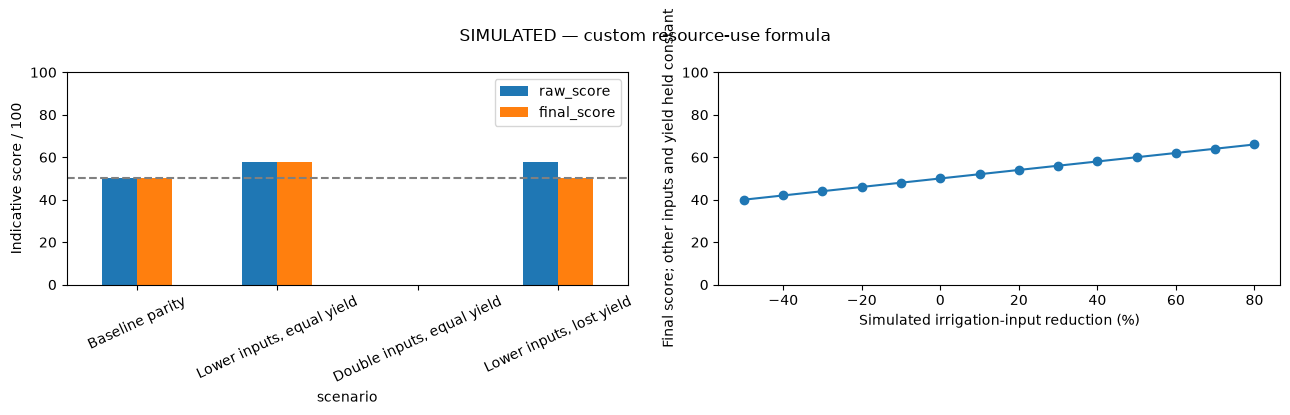

In [4]:
def compare(record, reference=baseline):
    return score_sustainability(reference, record, comparable=True, comparison_note=COMPARISON_NOTE)


assert math.isclose(compare(baseline)["score"], 50.0)
assert math.isclose(result["score"], 57.75)
doubled = {**baseline, **{field: baseline[field] * 2 for field in WEIGHTS}}
assert math.isclose(compare(doubled)["score"], 0.0)
lost_yield = {**current, "harvest_kg": baseline["harvest_kg"] * 0.8}
assert compare(lost_yield)["yield_gate_applied"] and compare(lost_yield)["score"] <= 50
scaled = {**current, **{field: current[field] * 2 for field in REQUIRED_NUMBERS}}
assert math.isclose(compare(scaled)["score"], result["score"])
assert score_sustainability(baseline, current)["score"] is None
assert compare({**current, "water_m3": None})["score"] is None
assert compare({**current, "nitrogen_kg": float("nan")})["score"] is None
assert compare({**current, "crop": "rice"})["score"] is None
assert compare(current, {**baseline, "water_m3": 0.0})["score"] is None
assert compare({**current, "data_kind": "measured"})["score"] is None

scenario_rows = []
for label, record in [("Baseline parity", baseline), ("Lower inputs, equal yield", current),
                      ("Double inputs, equal yield", doubled), ("Lower inputs, lost yield", lost_yield)]:
    value = compare(record)
    scenario_rows.append({"scenario": label, "raw_score": value["raw_score"],
                          "final_score": value["score"], "yield_gate": value["yield_gate_applied"]})
scenario_table = pd.DataFrame(scenario_rows)
display(scenario_table)
print("Formula checks passed.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scenario_table.set_index("scenario")[["raw_score", "final_score"]].plot.bar(ax=axes[0], rot=25)
axes[0].axhline(50, color="gray", linestyle="--")
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Indicative score / 100")
reductions = list(range(-50, 81, 10))
sensitivity = [compare({**baseline, "water_m3": baseline["water_m3"] * (1 - percent / 100)})["score"]
               for percent in reductions]
axes[1].plot(reductions, sensitivity, marker="o")
axes[1].set_xlabel("Simulated irrigation-input reduction (%)")
axes[1].set_ylabel("Final score; other inputs and yield held constant")
axes[1].set_ylim(0, 100)
fig.suptitle("SIMULATED — custom resource-use formula")
fig.tight_layout()
plt.show()


## Save the report

Export the inputs, component scores, weights, yield adjustment, and formula version.
Attributing savings to the software needs a controlled comparison. CO₂ estimates would also require emissions factors and a complete accounting scope.

In [5]:
output_dir = ROOT / "outputs/metrics"
figure_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
report = {"created_at_utc": datetime.now(timezone.utc).isoformat(), **result,
          "formula": {"intensity": "resource_total / cultivated_area_ha",
                      "relative_reduction": "(baseline_intensity - current_intensity) / baseline_intensity",
                      "component_score": "clip(50 + 50 * relative_reduction, 0, 100)",
                      "raw_score": "weighted sum of component scores",
                      "final_score": "min(raw_score, 50) if yield_retention_ratio < 0.95 else raw_score"}}
(output_dir / "sustainability_demo_report.json").write_text(
    json.dumps(report, indent=2, allow_nan=False), encoding="utf-8")
pd.DataFrame(result["components"]).to_csv(output_dir / "sustainability_demo_components.csv", index=False)
scenario_table.to_csv(output_dir / "sustainability_demo_scenarios.csv", index=False)
fig.savefig(figure_dir / "sustainability_demo_sensitivity.png", dpi=160, bbox_inches="tight")
print("Saved simulated comparison and formula documentation.")


Saved simulated comparison and formula documentation.


## Integration notes

Move the reviewed calculation into `services/sustainability.py` with its units and formula version.
Keep baseline evidence, missing-input handling, and simulated labels in the response.
Irrigation predictions and suggested volumes cannot be reported as measured savings.
Review the weights and yield constraint before using the score for farm decisions.